# 📊 Unemployment Analysis with Python
### CodeAlpha Data Science Internship — Task 2

**Objective:** Analyze unemployment trends in India, investigate the devastating impact of COVID-19, identify regional patterns, and present actionable policy insights.

| Detail | Info |
|--------|------|
| Dataset 1 | Unemployment in India — 768 records (state-level, monthly) |
| Dataset 2 | Unemployment Rate up to Nov 2020 — 267 records (with geo-coordinates) |
| Approach | EDA → Preprocessing → Trend Analysis → COVID-19 Impact → Regional Insights |


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. Load Datasets

In [2]:
# Dataset 1: Detailed state-level unemployment data
df1 = pd.read_csv('data/Unemployment_in_India.csv')

# Dataset 2: Rate data with geo coordinates
df2 = pd.read_csv('data/Unemployment_Rate_upto_11_2020.csv')

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

print("\nDataset 1 — First 5 rows:")
df1.head()

Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)

Dataset 1 — First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
print("Dataset 2 — First 5 rows:")
df2.head()

Dataset 2 — First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. EDA — Dataset 1 (Unemployment in India)

In [4]:
print("Dataset 1 Info:")
df1.info()
print("\nColumn names:")
print(df1.columns.tolist())

Dataset 1 Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [5]:
print("Missing values (Dataset 1):")
print(df1.isnull().sum())
print(f"\nTotal missing rows (completely blank): {df1.isnull().all(axis=1).sum()}")
print("\nStatistical Summary:")
df1.describe().round(3)

Missing values (Dataset 1):
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Total missing rows (completely blank): 28

Statistical Summary:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000,7.400000e+02,740.000
mean,11.788,7.204460e+06,42.630
std,10.721,8.087988e+06,8.111
min,0.000,4.942000e+04,13.330
25%,4.658,1.190404e+06,38.062
50%,8.350,4.744178e+06,41.160
75%,15.888,1.127549e+07,45.505
max,76.740,4.577751e+07,72.570


In [6]:
print("Unique Regions:", df1['Region'].dropna().nunique())
print("Regions:", sorted(df1['Region'].dropna().unique()))
print("\nAreas:", df1['Area'].dropna().unique())
print("\nFrequency:", df1[' Frequency'].dropna().unique())

Unique Regions: 28
Regions: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Areas: <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str

Frequency: <StringArray>
[' Monthly', 'Monthly']
Length: 2, dtype: str


## 4. EDA — Dataset 2 (Unemployment Rate with Geo-data)

In [7]:
print("Dataset 2 Info:")
df2.info()
print("\nMissing values:")
print(df2.isnull().sum())
print("\nStatistical Summary:")
df2.describe().round(3)

Dataset 2 Info:
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB

Missing values:
Region                            

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000,2.670000e+02,267.000,267.000,267.000
mean,12.237,1.396211e+07,41.682,22.826,80.532
std,10.803,1.336632e+07,7.845,6.271,5.832
min,0.500,1.175420e+05,16.770,10.850,71.192
25%,4.845,2.838930e+06,37.265,18.112,76.086
50%,9.650,9.732417e+06,40.390,23.610,79.019
75%,16.755,2.187869e+07,44.055,27.278,85.280
max,75.850,5.943376e+07,69.690,33.778,92.938


## 5. Data Preprocessing

In [8]:
# ---- Clean Dataset 1 ----
df1_clean = df1.dropna().copy()

# Strip whitespace from column names
df1_clean.columns = df1_clean.columns.str.strip()

# Rename columns for clarity
df1_clean.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Frequency': 'Frequency'
}, inplace=True)

# Parse dates
df1_clean['Date'] = pd.to_datetime(df1_clean['Date'].str.strip(), format='%d-%m-%Y')
df1_clean['Month'] = df1_clean['Date'].dt.month
df1_clean['Year']  = df1_clean['Date'].dt.year
df1_clean['YearMonth'] = df1_clean['Date'].dt.to_period('M')
df1_clean['MonthName'] = df1_clean['Date'].dt.strftime('%b')

# Mark COVID period (lockdown started March 2020)
df1_clean['COVID_Period'] = df1_clean['Date'].apply(
    lambda d: 'Post-COVID (≥Mar 2020)' if d >= pd.Timestamp('2020-03-01') else 'Pre-COVID (<Mar 2020)'
)

print(f"Cleaned Dataset 1: {df1_clean.shape[0]} rows × {df1_clean.shape[1]} cols")
print(f"Date range: {df1_clean['Date'].min().date()} → {df1_clean['Date'].max().date()}")
df1_clean.head()

Cleaned Dataset 1: 740 rows × 12 cols
Date range: 2019-05-31 → 2020-06-30


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year,YearMonth,MonthName,COVID_Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019,2019-05,May,Pre-COVID (<Mar 2020)
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019,2019-06,Jun,Pre-COVID (<Mar 2020)
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019,2019-07,Jul,Pre-COVID (<Mar 2020)
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019,2019-08,Aug,Pre-COVID (<Mar 2020)
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019,2019-09,Sep,Pre-COVID (<Mar 2020)


In [9]:
# ---- Clean Dataset 2 ----
df2_clean = df2.copy()
df2_clean.columns = df2_clean.columns.str.strip()

df2_clean.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'State_Category',
    'Frequency': 'Frequency'
}, inplace=True)

df2_clean['Date'] = pd.to_datetime(df2_clean['Date'].str.strip(), format='%d-%m-%Y')
df2_clean['YearMonth'] = df2_clean['Date'].dt.to_period('M')
df2_clean['COVID_Period'] = df2_clean['Date'].apply(
    lambda d: 'Post-COVID' if d >= pd.Timestamp('2020-03-01') else 'Pre-COVID'
)

print(f"Cleaned Dataset 2: {df2_clean.shape}")
print(f"Date range: {df2_clean['Date'].min().date()} → {df2_clean['Date'].max().date()}")

Cleaned Dataset 2: (267, 11)
Date range: 2020-01-31 → 2020-10-31


## 6. Unemployment Trend Over Time

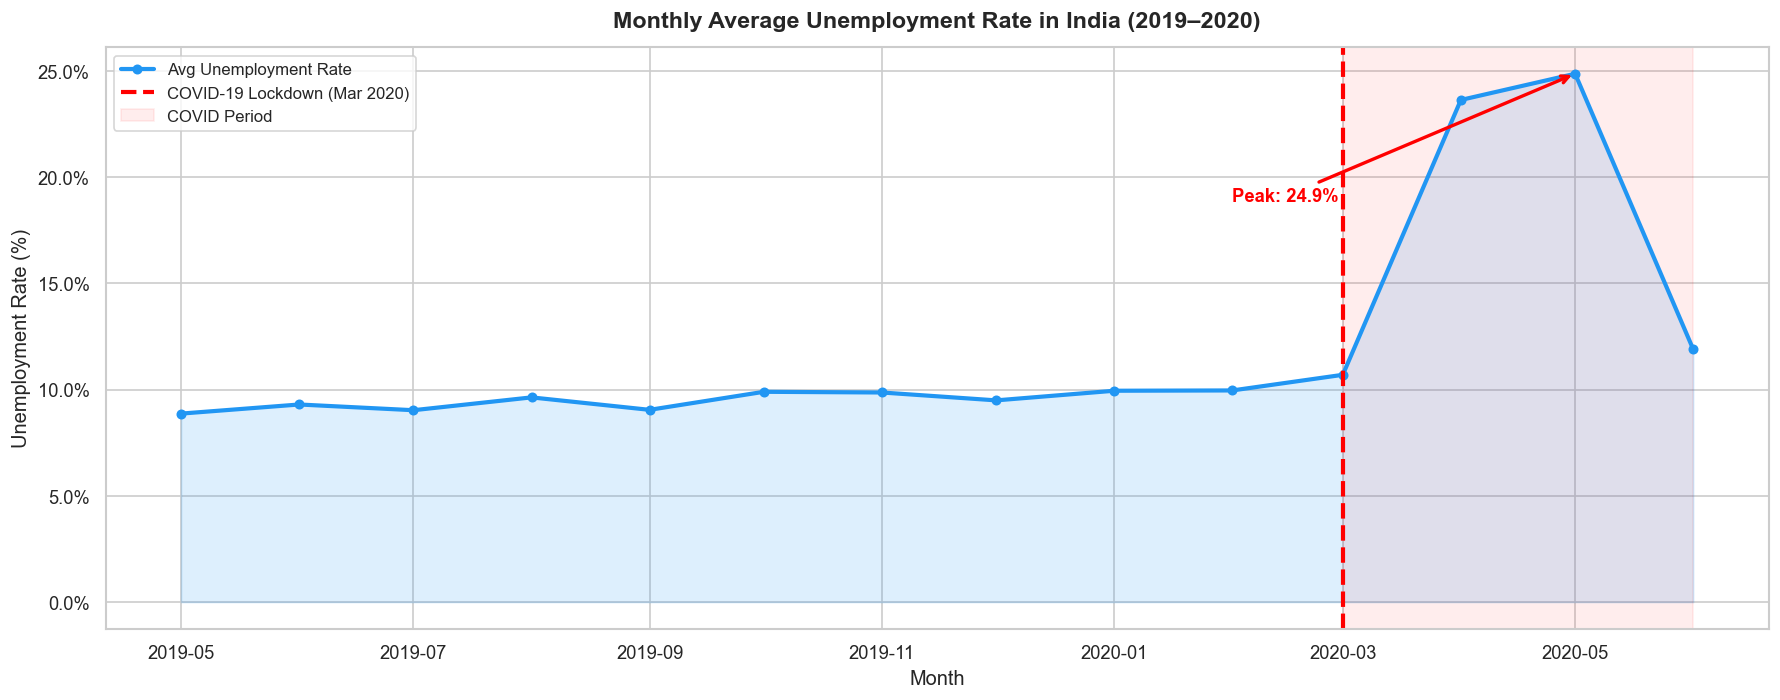

In [10]:
monthly_avg = (df1_clean.groupby('YearMonth')['Unemployment_Rate']
               .mean().reset_index())
monthly_avg['Date'] = monthly_avg['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
        color='#2196F3', linewidth=2.5, marker='o', markersize=5, label='Avg Unemployment Rate')
ax.fill_between(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
                alpha=0.15, color='#2196F3')

# COVID lockdown marker
lockdown = pd.Timestamp('2020-03-01')
ax.axvline(lockdown, color='red', linewidth=2.5, linestyle='--', label='COVID-19 Lockdown (Mar 2020)')
ax.axvspan(lockdown, monthly_avg['Date'].max(), alpha=0.07, color='red', label='COVID Period')

peak_idx = monthly_avg['Unemployment_Rate'].idxmax()
peak_row = monthly_avg.loc[peak_idx]
ax.annotate(f"Peak: {peak_row['Unemployment_Rate']:.1f}%",
            xy=(peak_row['Date'], peak_row['Unemployment_Rate']),
            xytext=(peak_row['Date'] - pd.DateOffset(months=3), peak_row['Unemployment_Rate'] - 6),
            arrowprops={'arrowstyle': '->', 'color': 'red', 'lw': 2},
            fontsize=11, color='red', fontweight='bold')

ax.set_title('Monthly Average Unemployment Rate in India (2019–2020)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

## 7. COVID-19 Impact Analysis

In [11]:
# Overall before vs after COVID
covid_compare = df1_clean.groupby('COVID_Period')['Unemployment_Rate'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)
print("COVID-19 Impact on Unemployment Rate:")
print(covid_compare)

pre  = df1_clean[df1_clean['COVID_Period'] == 'Pre-COVID (<Mar 2020)']['Unemployment_Rate']
post = df1_clean[df1_clean['COVID_Period'] == 'Post-COVID (≥Mar 2020)']['Unemployment_Rate']
print(f"\n⚡ Average increase due to COVID: +{post.mean() - pre.mean():.2f} percentage points")
print(f"⚡ Median increase due to COVID:  +{post.median() - pre.median():.2f} percentage points")

COVID-19 Impact on Unemployment Rate:
                         mean  median    std  min    max
COVID_Period                                            
Post-COVID (≥Mar 2020)  17.77   14.52  15.03  0.0  76.74
Pre-COVID (<Mar 2020)    9.51    7.12   7.36  0.0  34.69

⚡ Average increase due to COVID: +8.26 percentage points
⚡ Median increase due to COVID:  +7.40 percentage points


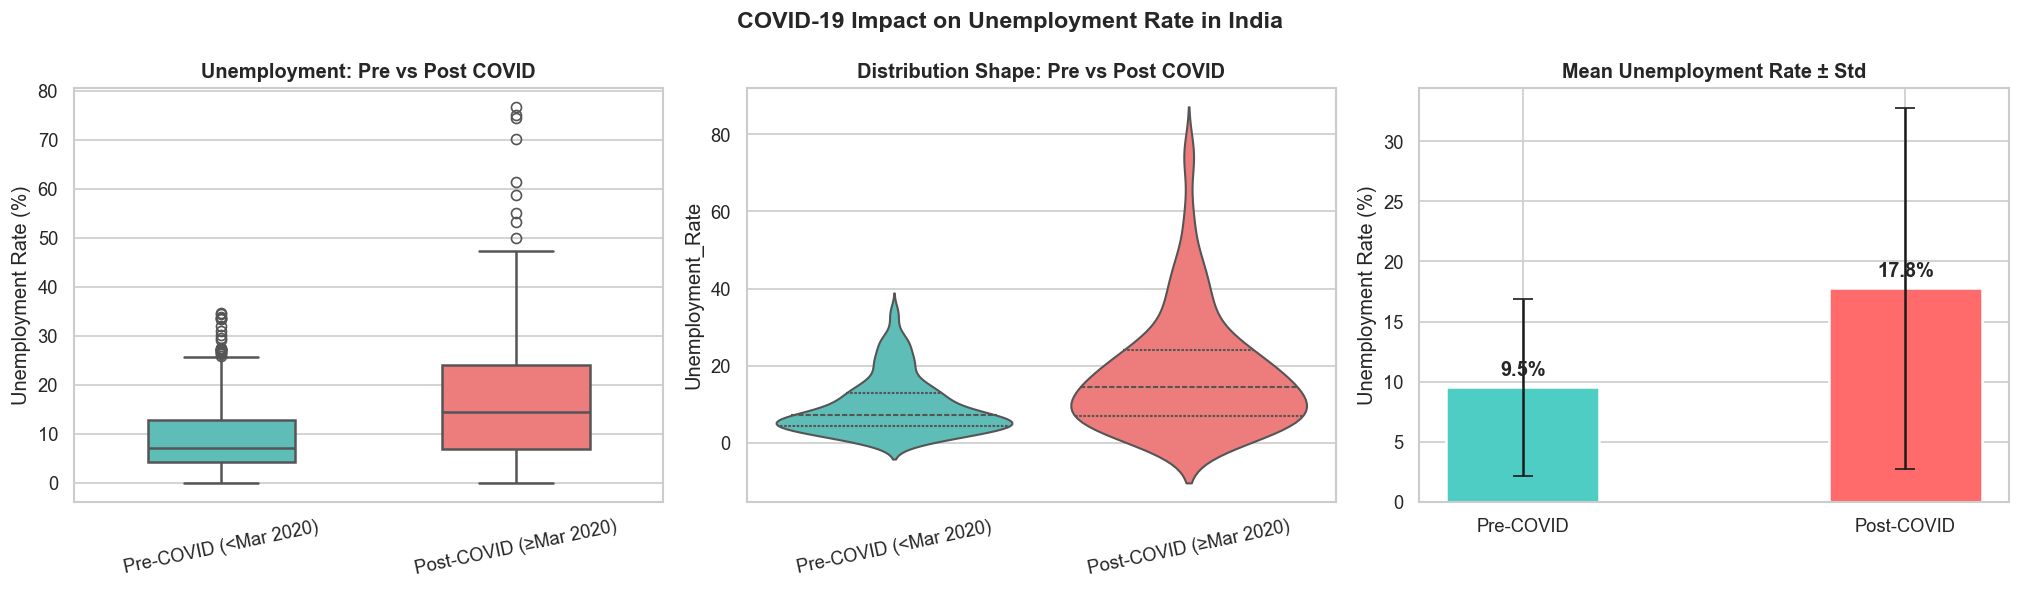

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Box plot: Pre vs Post COVID
palette = {'Pre-COVID (<Mar 2020)': '#4ECDC4', 'Post-COVID (≥Mar 2020)': '#FF6B6B'}
sns.boxplot(data=df1_clean, x='COVID_Period', y='Unemployment_Rate',
            palette=palette, ax=axes[0], width=0.5, linewidth=1.5)
axes[0].set_title('Unemployment: Pre vs Post COVID', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].tick_params(axis='x', rotation=12)

# Violin plot
sns.violinplot(data=df1_clean, x='COVID_Period', y='Unemployment_Rate',
               palette=palette, ax=axes[1], inner='quartile')
axes[1].set_title('Distribution Shape: Pre vs Post COVID', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=12)

# Bar: mean with error bar
means = [pre.mean(), post.mean()]
stds  = [pre.std(), post.std()]
bars = axes[2].bar(['Pre-COVID', 'Post-COVID'], means, yerr=stds, capsize=6,
                    color=['#4ECDC4', '#FF6B6B'], edgecolor='white', linewidth=1.5, width=0.4)
axes[2].set_title('Mean Unemployment Rate ± Std', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Unemployment Rate (%)')
for bar, val in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('COVID-19 Impact on Unemployment Rate in India', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Regional Analysis

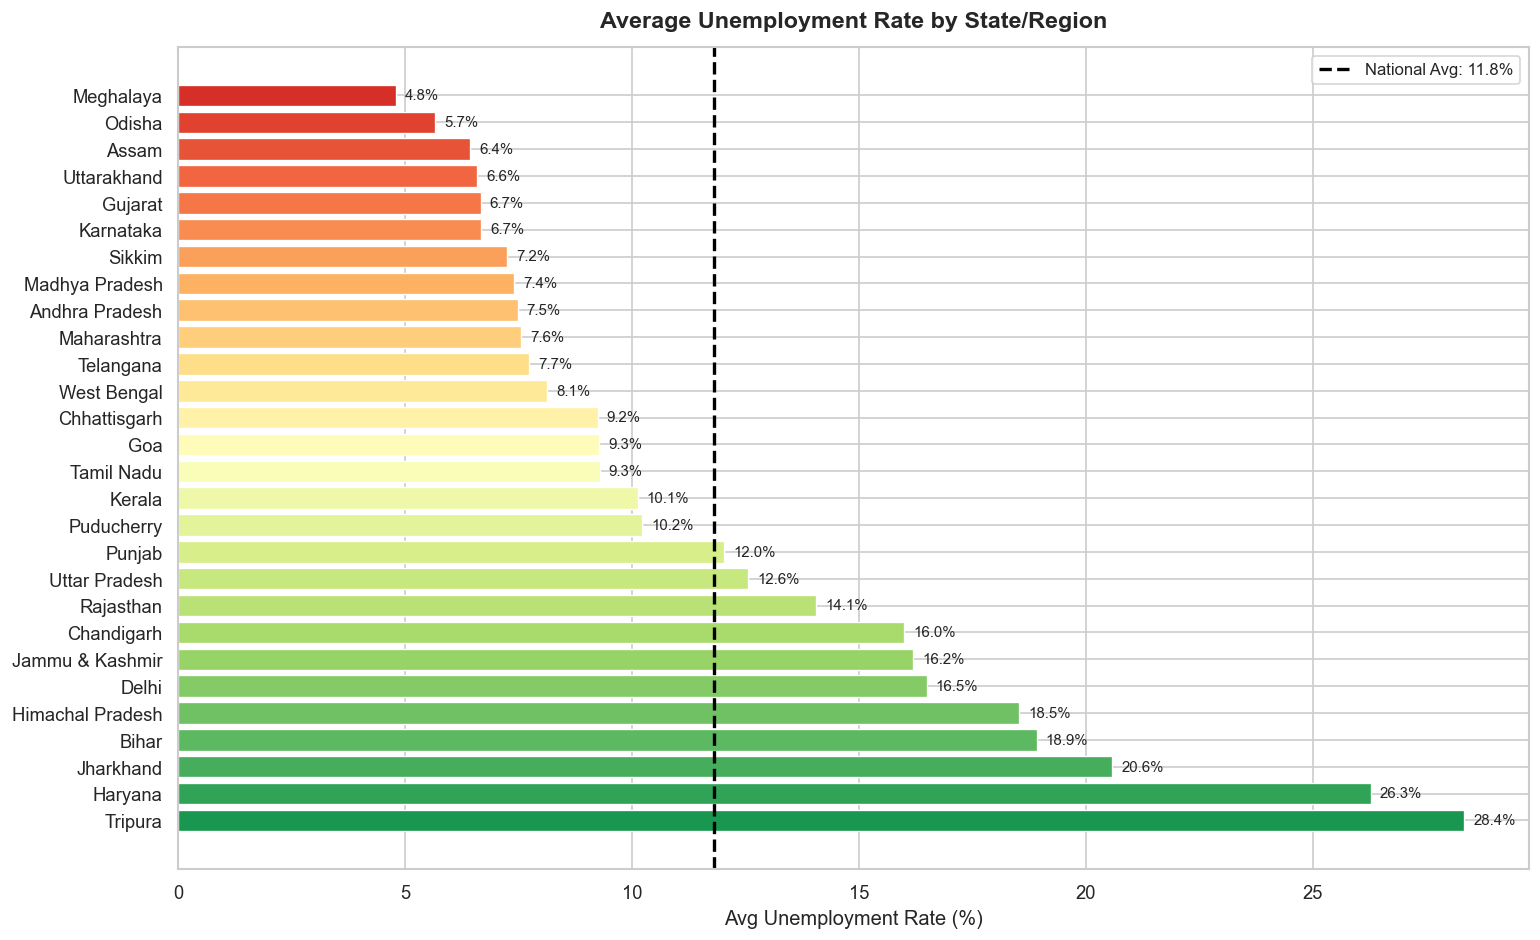

In [13]:
region_stats = (df1_clean.groupby('Region')['Unemployment_Rate']
                .mean().sort_values(ascending=False).reset_index())
region_stats.columns = ['Region', 'Avg_Unemployment_Rate']

fig, ax = plt.subplots(figsize=(13, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(region_stats)))
bars = ax.barh(region_stats['Region'], region_stats['Avg_Unemployment_Rate'],
               color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(region_stats['Avg_Unemployment_Rate'].mean(), color='black',
           linewidth=2, linestyle='--', label=f"National Avg: {region_stats['Avg_Unemployment_Rate'].mean():.1f}%")
ax.set_title('Average Unemployment Rate by State/Region', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Avg Unemployment Rate (%)', fontsize=12)
ax.legend(fontsize=10)
for bar, val in zip(bars, region_stats['Avg_Unemployment_Rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Rural vs Urban Unemployment

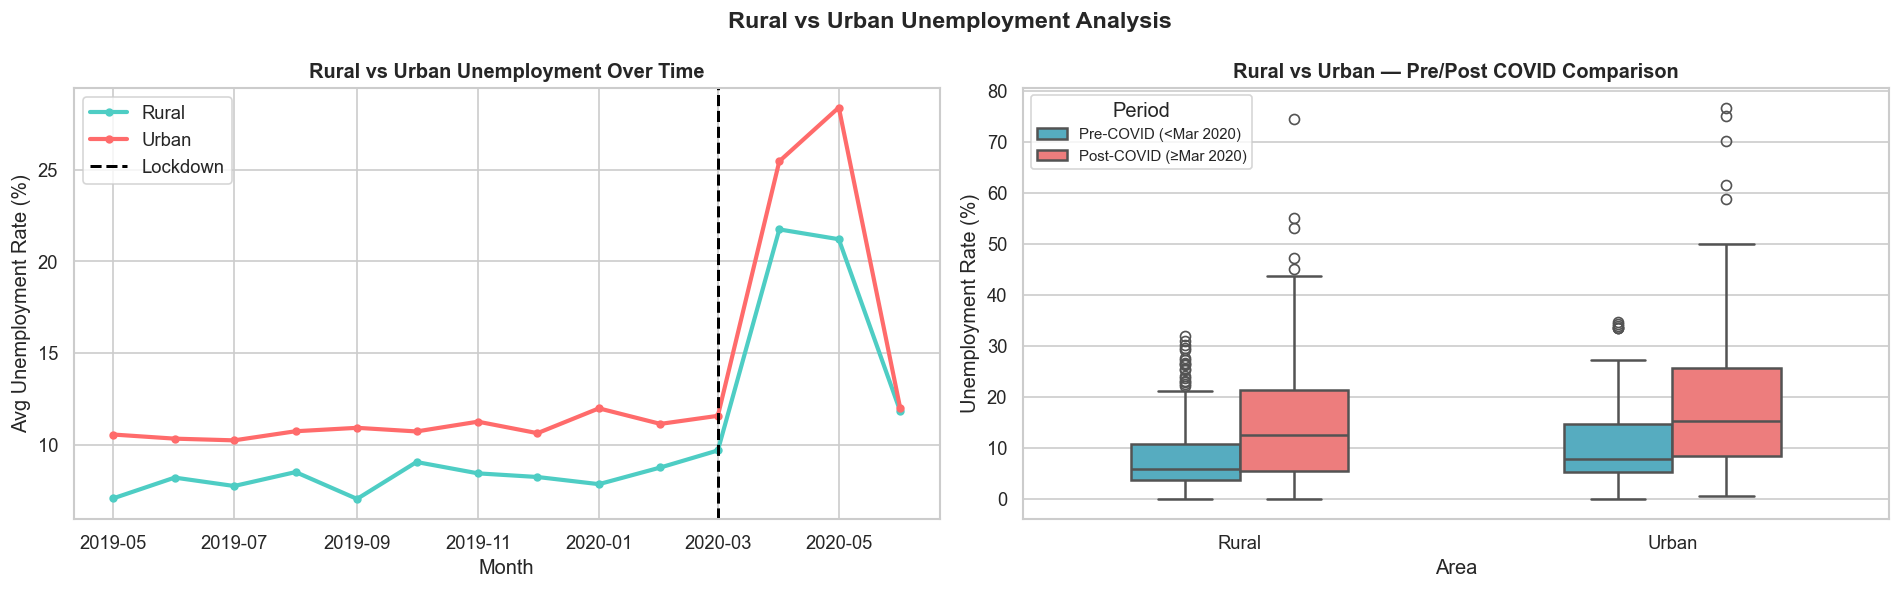

In [14]:
area_monthly = (df1_clean.groupby(['YearMonth', 'Area'])['Unemployment_Rate']
                .mean().reset_index())
area_monthly['Date'] = area_monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Line plot over time
area_colors = {'Rural': '#4ECDC4', 'Urban': '#FF6B6B'}
for area, grp in area_monthly.groupby('Area'):
    axes[0].plot(grp['Date'], grp['Unemployment_Rate'],
                 label=area, color=area_colors[area], linewidth=2.5, marker='o', markersize=4)
axes[0].axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--', linewidth=1.8, label='Lockdown')
axes[0].set_title('Rural vs Urban Unemployment Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Unemployment Rate (%)')
axes[0].legend()

# Box comparison
sns.boxplot(data=df1_clean, x='Area', y='Unemployment_Rate', hue='COVID_Period',
            palette={'Pre-COVID (<Mar 2020)': '#45B7D1', 'Post-COVID (≥Mar 2020)': '#FF6B6B'},
            ax=axes[1], width=0.5, linewidth=1.5)
axes[1].set_title('Rural vs Urban — Pre/Post COVID Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Area')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].legend(title='Period', fontsize=9)

plt.suptitle('Rural vs Urban Unemployment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Month-wise Heatmap

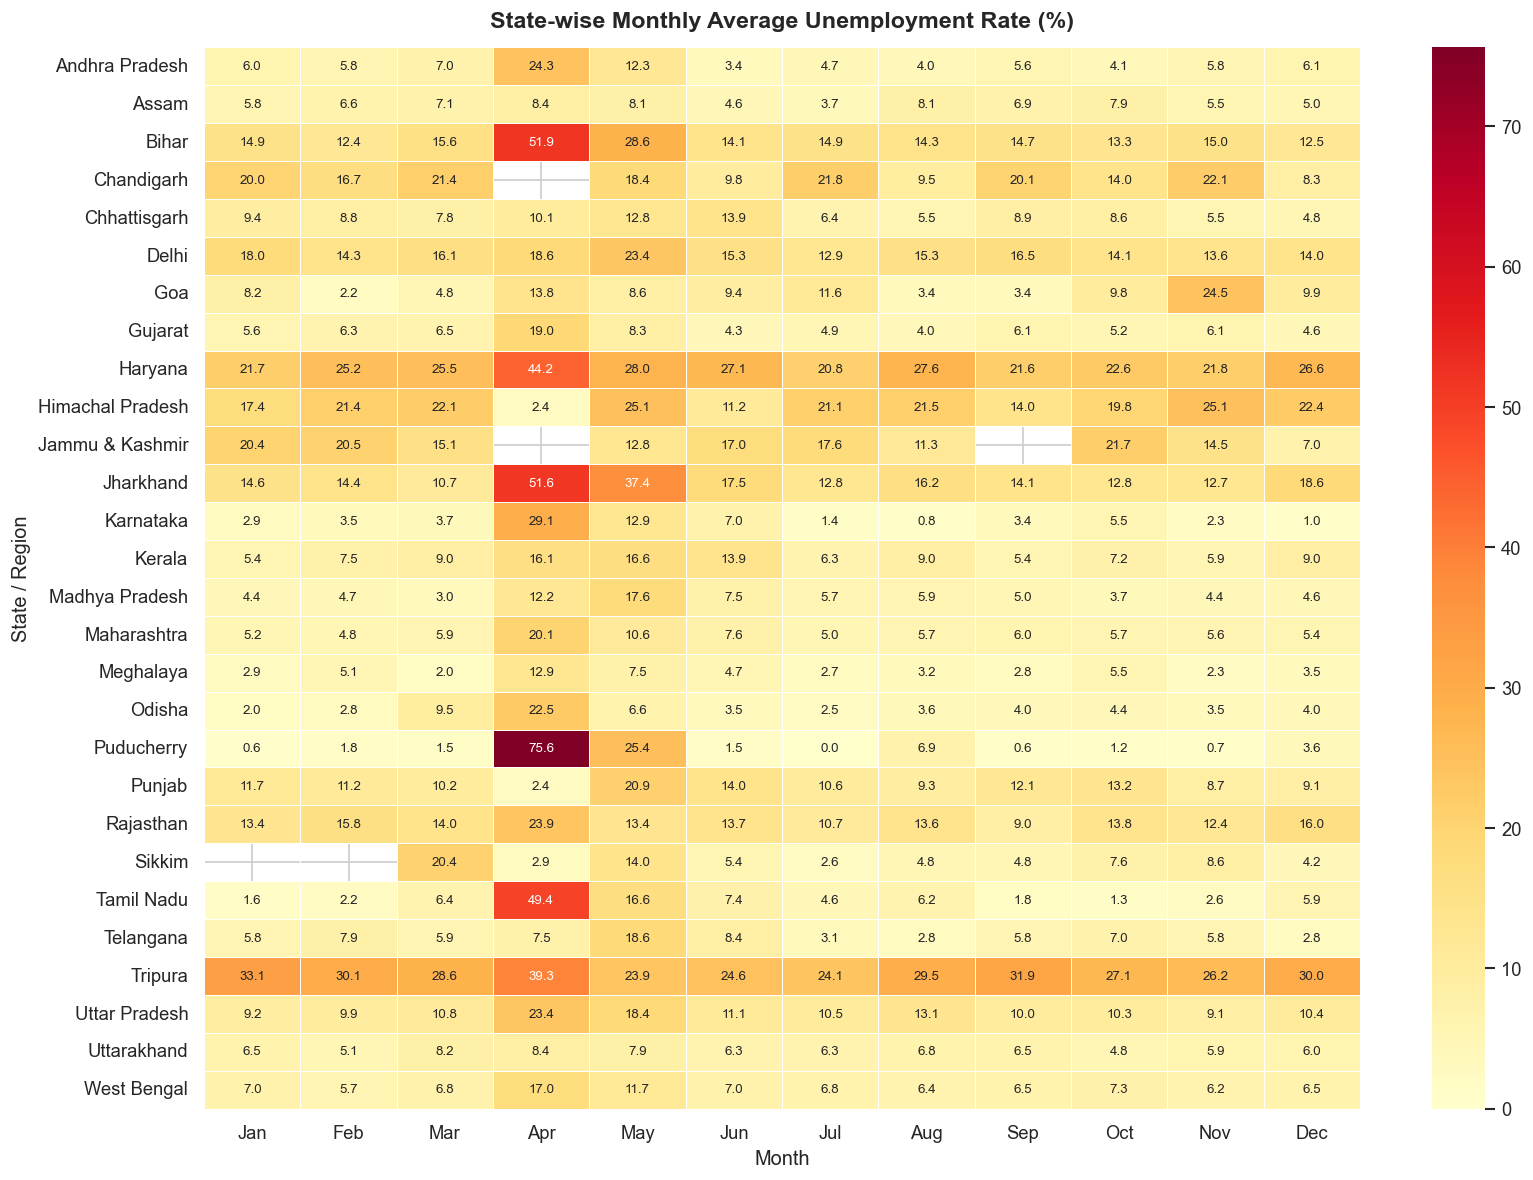

In [15]:
month_region = (df1_clean.groupby(['Region', 'MonthName'])['Unemployment_Rate']
                .mean().unstack())

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_region = month_region.reindex(columns=[m for m in month_order if m in month_region.columns])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(month_region, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('State-wise Monthly Average Unemployment Rate (%)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('State / Region', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Labour Participation Rate Analysis

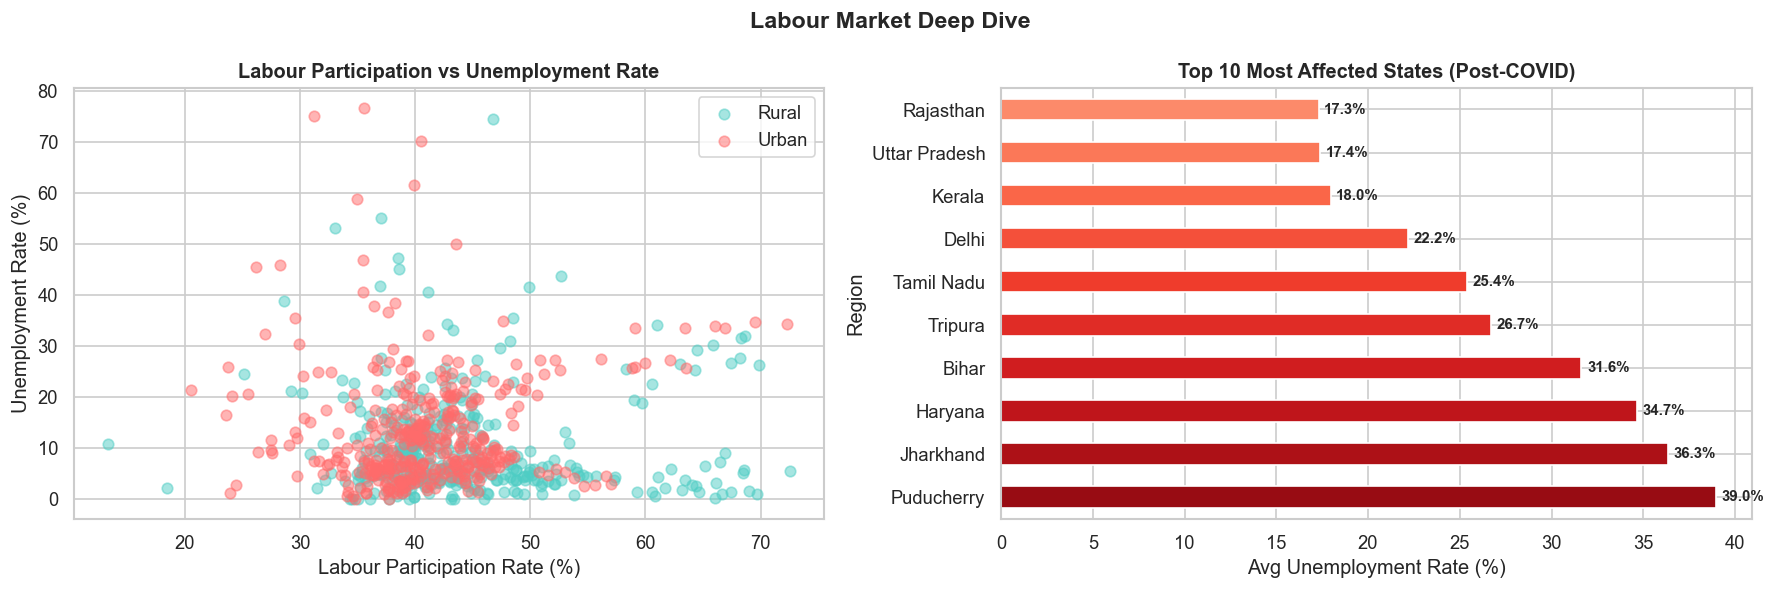

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Unemployment Rate vs Labour Participation Rate
scatter_colors = {'Rural': '#4ECDC4', 'Urban': '#FF6B6B'}
for area, grp in df1_clean.groupby('Area'):
    axes[0].scatter(grp['Labour_Participation_Rate'], grp['Unemployment_Rate'],
                    label=area, color=scatter_colors[area], alpha=0.5, s=40)
axes[0].set_title('Labour Participation vs Unemployment Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Labour Participation Rate (%)')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].legend()

# Top 5 most-affected states during COVID
top_covid = (df1_clean[df1_clean['COVID_Period'] == 'Post-COVID (≥Mar 2020)']
             .groupby('Region')['Unemployment_Rate'].mean()
             .sort_values(ascending=False).head(10))
top_covid.plot(kind='barh', ax=axes[1],
               color=plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1],
               edgecolor='white')
axes[1].set_title('Top 10 Most Affected States (Post-COVID)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Unemployment Rate (%)')
for i, val in enumerate(top_covid):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Labour Market Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Key Findings & Policy Insights

### COVID-19 Impact
- **Unemployment spiked dramatically** post March 2020 lockdown — jumping from ~7-8% to over **23%** at peak (April–May 2020).
- The surge was **universal across all states** — no region was spared.
- Recovery began in June 2020 but remained **above pre-COVID baseline** throughout the rest of 2020.

### Regional Patterns
- States like **Tripura, Haryana, Jharkhand, and Bihar** consistently show higher unemployment.
- Southern states generally have **more stable, lower unemployment rates**.

### Rural vs Urban
- **Urban areas** were hit harder during COVID due to service sector shutdowns.
- **Rural areas** showed more resilience, cushioned by agriculture sector activity.

### Policy Recommendations
1. **Emergency income support** for urban informal workers during crises.
2. **Skill development programs** targeting states with chronically high unemployment.
3. **Investment in rural infrastructure** to sustain rural employment buffers.
4. **Real-time monitoring dashboards** using this data for early warning systems.
